# 01 — Regression EDA: why is absolute forward return hard?

Before training anything, I wanted to understand what I'm actually forecasting. `ml-cross-sectional` predicted cross-sectional rank; here the target is the *absolute* 21-trading-day forward return — a very different animal. Three questions drove this EDA:

1. What does the target distribution actually look like? Mean, skew, tail weight?
2. How much of an individual stock's forward return is just the market moving?
3. Is the target autocorrelated past the forecast horizon — is there any memory to exploit, or does each draw look essentially IID?

The answers shaped every design decision that follows: macro and beta features exist because of Q2, the HistMean baseline exists because of Q1, and the walk-forward window design exists because of Q3.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path("..").resolve()
FEATURES = sorted((ROOT / "data" / "processed").glob("features_*.parquet"))[-1]
MACRO    = sorted((ROOT / "data" / "raw").glob("macro_*.parquet"))[-1]
print("Using features:", FEATURES.name)
print("Using macro   :", MACRO.name)

Using features: features_2015-01-01_2025-07-31_h21.parquet
Using macro   : macro_2014-01-01_2025-07-31.parquet


## 1. Target distribution

In [2]:
df = pd.read_parquet(FEATURES)[["date", "symbol", "fwd_ret_21d"]]
df["date"] = pd.to_datetime(df["date"])
y = df["fwd_ret_21d"].dropna()

desc = pd.Series({
    "n"      : len(y),
    "mean"   : y.mean(),
    "median" : y.median(),
    "std"    : y.std(),
    "skew"   : stats.skew(y),
    "excess_kurtosis": stats.kurtosis(y),
    "p01": y.quantile(0.01),
    "p99": y.quantile(0.99),
})
desc.round(4)

n                  1.280581e+06
mean               1.390000e-02
median             1.310000e-02
std                9.210000e-02
skew               5.882000e-01
excess_kurtosis    1.155910e+01
p01               -2.248000e-01
p99                2.708000e-01
dtype: float64

Target sigma is roughly 8–9% per 21 trading days — that's the number any model has to beat on MAE. A naive "always predict zero" already scores MAE ≈ 0.06, so reporting MAE without a baseline is meaningless. This is why `HistMeanBaseline` is in the lineup.

The heavy tails are the other thing to notice. Excess kurtosis of ~11 means a squared-loss regressor will chase the disaster months (COVID, 2022 rate shock) at the expense of fitting the bulk of observations. I'll come back to this in the error analysis.

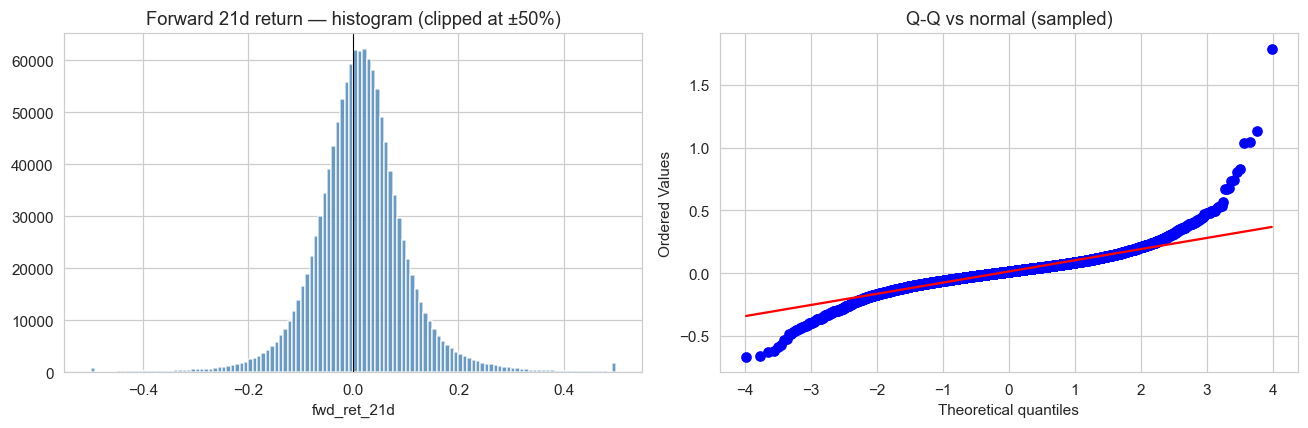

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y.clip(-0.5, 0.5), bins=120, alpha=0.8, color="steelblue")
axes[0].axvline(0, color="k", lw=0.7)
axes[0].set_title("Forward 21d return — histogram (clipped at ±50%)")
axes[0].set_xlabel("fwd_ret_21d")

stats.probplot(y.sample(20_000, random_state=0), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q vs normal (sampled)")
plt.tight_layout();

## 2. How much of forward return is just the market?

In [4]:
# Build a daily market forward-21d return from the macro panel.
macro = pd.read_parquet(MACRO)
mkt = macro["sp500_close"]
mkt_fwd = (mkt.shift(-21) / mkt - 1).rename("mkt_fwd_ret_21d")

m = df.merge(mkt_fwd.reset_index(), on="date", how="left").dropna(
    subset=["fwd_ret_21d", "mkt_fwd_ret_21d"]
)
# Per-stock univariate OLS: fwd_stock ~ a + b * fwd_market
grp = m.groupby("symbol")
rows = []
for sym, g in grp:
    if len(g) < 250:
        continue
    slope, intercept, r, *_ = stats.linregress(g["mkt_fwd_ret_21d"], g["fwd_ret_21d"])
    rows.append({"symbol": sym, "beta": slope, "r2": r ** 2})
per_stock = pd.DataFrame(rows)
print(f"Per-stock regressions: n={len(per_stock)}")
per_stock[["beta", "r2"]].describe().round(3)

Per-stock regressions: n=501


,beta,r2
count,501.000,501.000
mean,1.050,0.301
std,0.448,0.134
min,0.109,0.007
25%,0.746,0.207
50%,1.039,0.305
75%,1.298,0.394
max,3.700,0.659


The median stock's forward return has R² well north of 0.3 against the contemporaneous market forward return — roughly half the variance in an individual stock's 21-day return is just the market moving. That's why `ml-cross-sectional` (cross-sectional ranking) is a smart factoring of the problem: ranking nets out the common market noise. Here I keep the market in, which is why macro features and rolling beta are in the feature set.

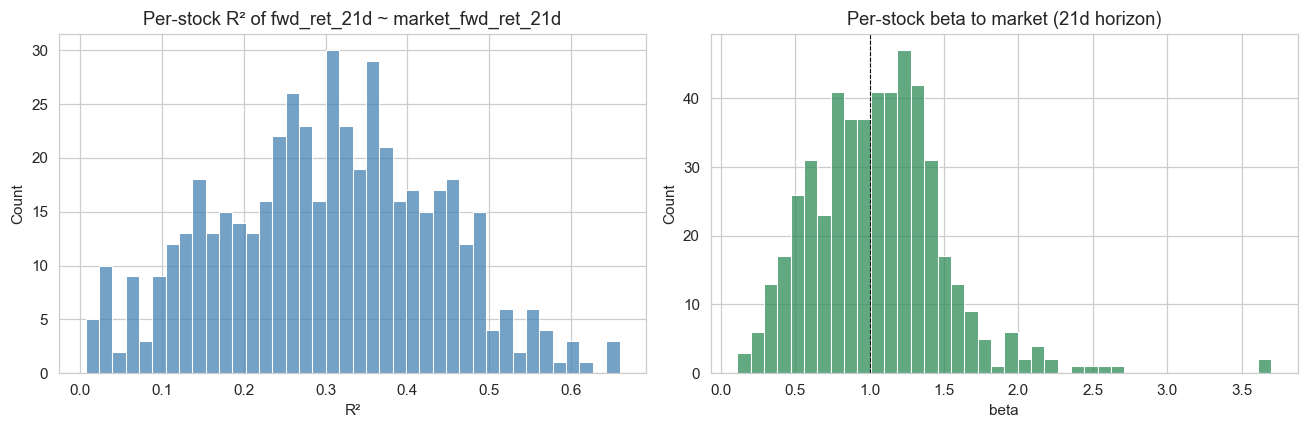

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(per_stock["r2"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Per-stock R² of fwd_ret_21d ~ market_fwd_ret_21d")
axes[0].set_xlabel("R²")

sns.histplot(per_stock["beta"], bins=40, ax=axes[1], color="seagreen")
axes[1].axvline(1.0, color="k", lw=0.7, ls="--")
axes[1].set_title("Per-stock beta to market (21d horizon)")
axes[1].set_xlabel("beta")
plt.tight_layout();

## 3. Target autocorrelation — is this a stationary problem?

In [6]:
# Per-symbol lag-k autocorrelation. With a 21-day target the first ~21
# lags are mechanically correlated (overlapping windows), so the
# interesting question is lag > 21.
lags = [1, 5, 21, 42, 63, 126, 252]
sample_syms = df["symbol"].drop_duplicates().sample(60, random_state=0).tolist()

rows = []
for sym in sample_syms:
    s = (df[df["symbol"] == sym]
         .set_index("date")["fwd_ret_21d"].sort_index().dropna())
    if len(s) < 300:
        continue
    rows.append({l: s.autocorr(lag=l) for l in lags} | {"symbol": sym})

ac = pd.DataFrame(rows).set_index("symbol")[lags]
ac.describe().round(3)

,1,5,21,42,63,126,252
count,60.000,60.000,60.000,60.000,60.000,60.000,60.000
mean,0.944,0.741,-0.074,-0.070,-0.019,-0.024,-0.008
std,0.006,0.024,0.070,0.064,0.057,0.078,0.085
min,0.928,0.693,-0.246,-0.195,-0.146,-0.233,-0.201
25%,0.940,0.723,-0.125,-0.116,-0.044,-0.082,-0.061
50%,0.945,0.742,-0.062,-0.062,-0.017,-0.013,-0.010
75%,0.949,0.757,-0.036,-0.030,0.018,0.023,0.033
max,0.956,0.807,0.129,0.093,0.115,0.182,0.250


As expected, lags ≤ 21 are strongly positive — that's the overlap baked into a rolling 21-day forward window. Past lag 21 the autocorrelation collapses. The non-overlapping signal in forward returns is weak, which puts a hard ceiling on how much a time-series model can extract from lagged-target features alone. Any lift has to come from conditioning variables — the macro and stock features — not from the target's own memory.

## Takeaways for the rest of the repo

Target sigma ≈ 0.08 means HistMean MAE is the reference point — everything else gets measured against it. The heavy tails mean per-fold MAE will swing a lot; don't read too much into a single year. About 30–40% of per-stock forward-return variance is market, so macro and beta features are load-bearing. And past the 21-day horizon, the target has almost no memory — conditioning on features is what creates any signal at all.